<h1>####################################################</h1>
<h1>Enterprise Vector Store ユースケース</h1>
<h1>PDFからEnterprise Vector Storeを作成する</h1>
<h1>####################################################</h1>

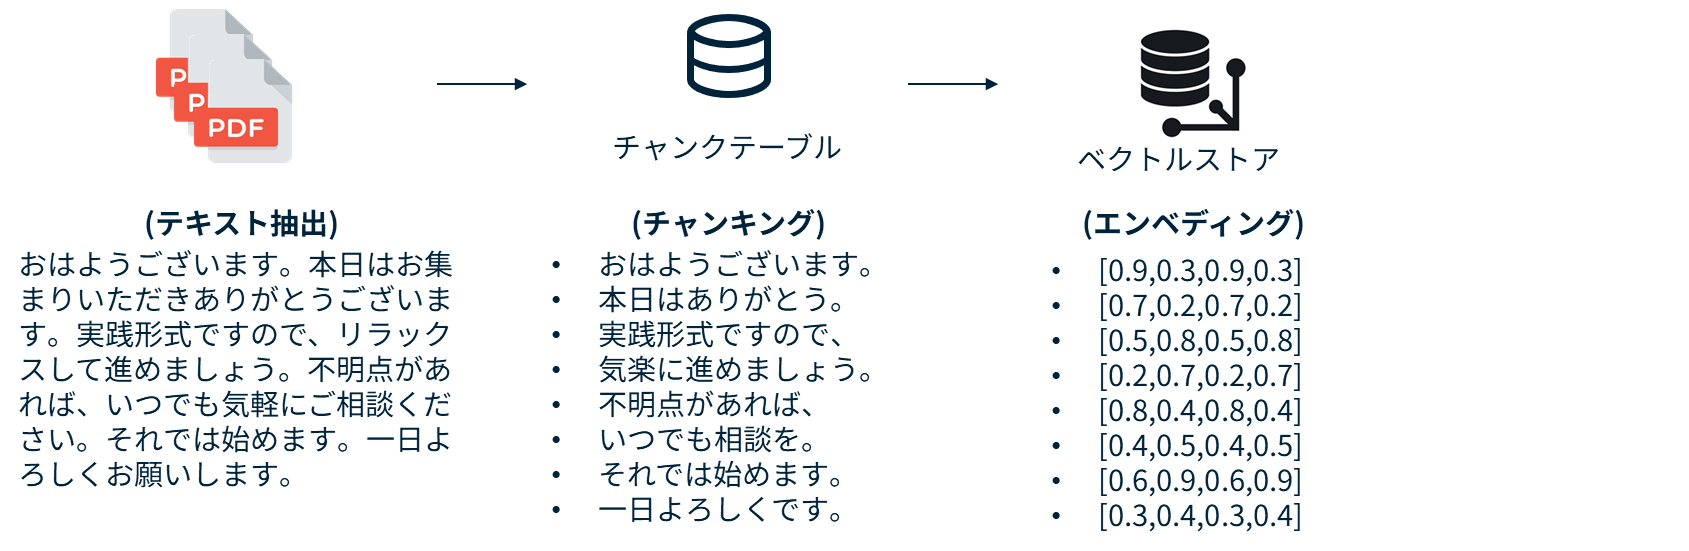

# 0. 事前準備作業(初回オプション)
---

## 0.1. 必要ライブラリインストール 
<font color="red">ライブラリをインストールしたら一時**カーネル**をリスタートしてください!!</font>

In [ ]:
!pip install -r requirements.txt

## 0.2. 環境ファイルの取得
(注釈) 通常は必要ない作業です。

In [ ]:
!cp /home/jovyan/JupyterLabRoot/VantageCloud_Lake/.config/.env    ./env
!cp /home/jovyan/JupyterLabRoot/VantageCloud_Lake/.config/*.pem   ./
!sed -i "s|pem_file='.*/|pem_file='|" env

# 1. 環境定義
---

## 1.1. ライブラリ読み込み

In [ ]:
import os
import time
import glob
from dotenv import load_dotenv,dotenv_values
from teradataml import *
from teradatagenai import VSManager, VectorStore
from teradataml import create_context, set_auth_token
import logging
from sqlalchemy import text

## 1.2. データフォルダ取得

In [ ]:
cwd = os.getcwd()
data_folder = os.path.join(cwd, "data")

# 2. ベクトルデータベース操作
---

## 2.1. データベース接続

In [ ]:
env_vars = dotenv_values("env")
eng = create_context(host=env_vars.get("host"), username=env_vars.get("username"), password=env_vars.get("my_variable"))
# 接続オブジェクトを取得します
con = get_connection()
# Set Query Band
con.execute(text("""SET query_band='APP=EVS_TEST_PDF;' UPDATE FOR SESSION;"""))

## 2.2. UES(User Execution Service)に認証トークンでセッション確立
(注釈) **UES** とは、pythonなどの外部ツールからVCL上で処理を実行するための共通実行サービスです。

In [ ]:
if set_auth_token(base_url=env_vars.get("ues_uri"),
                  pat_token=env_vars.get("access_token"), 
                  pem_file=env_vars.get("pem_file"),
                  valid_from=int(time.time())
                 ):
    print("セッション確立の成功")
else:
    print("セッション確立の失敗")

## 2.3. Vector Store ステータスの確認

In [ ]:
VSManager.health()

## 2.4. Vector Store の指定

In [ ]:
_vsname = f"""hands_on_{env_vars.get("username")}"""
print(f"あなたのベクトルストア名は {_vsname} です。")

In [ ]:
# ベクトルデータベースがまだ作成されていない場合はワーニングが出ます
document_vector_store = VectorStore(_vsname)

# 3. Vector Store の作成
---

## 3.1. アップロードされたファイルのチェック
(注釈) dataフォルダ配下のファイルの一覧をリストアップします

In [ ]:
supported_patterns = ["*.pdf"]
files = []
for pattern in supported_patterns:
    files.extend(glob.glob(os.path.join(data_folder, pattern)))

if len(files) == 0:
    raise FileNotFoundError("PDFファイルが見つかりません")
else:
    print(f"### PDFファイルの一覧 ({len(files)} Files) ###")
    for file in files:
        print(os.path.basename(file))

## 3.2. ベクトルストアの作成

In [ ]:
#ベクトルストアを削除する場合は このコメントを解除してDestory()する 
# document_vector_store.destroy()

In [ ]:
#ベクトルストアを更新する場合は このコメントを解除してupdate()する 
# document_vector_store.update(top_k=3)

In [ ]:
#ベクトルストア作成 
df=document_vector_store.status()
if df is None:
    document_vector_store.create(
        embeddings_model="amazon.titan-embed-text-v2:0",
        chat_completion_model="anthropic.claude-3-haiku-20240307-v1:0",
        search_algorithm="VECTORDISTANCE",
        top_k=10,
        object_names="ITPolicy",
        data_columns=["chunks"],
        vector_column="VectorIndex",
        optimized_chunking=True,
        document_files=files,
    )
else:
    print("ベクトルストアは既に存在しています!")

(注釈) ベクトルストア作成コマンドの主要なパラメータ説明

|**パラメータ**|**パラメータ名**|**値**|
|:-|:-|:-|
|**エンベディングモデル**|embeddings_model|AWS:<br>- amazon.titan-embed-text-v1<br>- amazon.titan-embed-image-v1<br>- amazon.titan-embed-text-v2:0|
|**チャットモデル**|chat_completion_model|AWS:<br>- anthropic.claude-3-haiku-20240307-v1:0<br>- anthropic.claude-instant-v1<br>- anthropic.claude-3-5-sonnet-20240620-v1:0|
|**サーチアルゴリズム**|search_algorithm|- VECTORDISTANCE<br>- KMEANS<br>- HNSW|
|**ベクトル距離**|metric|- EUCLIDEAN<br>- COSINE<br>- DOTPRODUCT|
|**検索結果の上位**|top_k|1～1024|
|**最適化チャンキング**|optimized_chunking|True:Teradata最適化チャンキング|
|**チャンクサイズ**|chunk_size|チャンクサイズ(optimized_chunking=Trueの時は無効)|
|**チャンキングテーブル名**|object_names|チャンクテーブル名|
|**チャンキングカラム名**|data_columns|チャンクしたカラムを格納するカラム名|
|**ベクトルカラム名**|vector_column|ベクトル値を格納するカラム名|
|**ファイルリスト**|document_files|PDFファイルの一覧を配列で指定します|

## 3.3. ステータスの確認 ***<font color="red">READY</font>*** になるまで待つ
(注釈) READYになるまでこのコマンドを繰り返し実行する

In [ ]:
document_vector_store.status()

## 3.4. ベクトルストアのリスト表示
(注釈) 現在あなたが管理(ADMIN)しているベクトルストアをリストします。

In [ ]:
df=VSManager.list()
df[df["permission"] == 'ADMIN']

## 3.5. ベクトルストアの詳細
(注釈) 今回あなたが作成したベクトルストアの詳細です。

In [ ]:
vs_df = document_vector_store.get_details()
# pandasに変換して見やすくする
pd_df = vs_df.to_pandas()
with pd.option_context('display.max_rows', None,'display.max_colwidth', 120):
    print(pd_df.head().T)

# 4. Enterprise Vector Store に質問
---

## 4. Enterprise Vector Store に質問してみる

In [ ]:
res = document_vector_store.ask(
    question="ドキュメントに記載されているパスワードポリシーを教えてください。文字数や使用できる文字、期間、使い回しの要件があれば教えてください",
    prompt="あなたは当社の社内規則・就業規則に精通した人事部のアシスタントです。"
)
print(res)

# 5. Vantageから切断
---

In [ ]:
remove_context()

<h1>####################################################</h1>
<h1>次のセッションの準備作業</h1>
<h1>####################################################</h1>

# Claude Desktop_config.jsonファイルの作成
---
次のハンズオンで使用するファイルを生成します。

In [ ]:
env_vars = dotenv_values("env")
_hst = env_vars.get("host")                            # Vantageの hostアドレス
_uid = env_vars.get("username")                        # Vantageの DBユーザ
_pwd = env_vars.get("my_variable")                     # Vantageの DBパスワード
_url = env_vars.get("ues_uri")                         # UES接続の URL
_tkn = env_vars.get("access_token")                    # UES接続の アクセストークン
_pem = os.path.basename(env_vars.get("pem_file"))      # UES接続の 認証用暗号化ファイル

In [ ]:
json_text = f"""
{{
  "mcpServers": {{
    "teradata": {{
      "command": "uvx",
      "args": [
        "teradata-mcp-server[tdvs]",
        "--profile",
        "dataScientist"
      ],
      "env": {{
        "DATABASE_URI": "teradata://{_uid}:{_pwd}@{_hst}:1025/{_uid}",
        "TD_BASE_URL": "{_host}",
        "TD_PAT": "{_tkn}",
        "TD_PEM": "{_pem}"
      }}
    }}
  }},
  "preferences": {{
    "menuBarEnabled": false,
    "legacyQuickEntryEnabled": false,
    "coworkScheduledTasksEnabled": false,
    "ccdScheduledTasksEnabled": false,
    "sidebarMode": "chat",
    "coworkWebSearchEnabled": true
  }}
}}
"""

**claude_desktop_config.json** ファイルを生成する

In [ ]:
with open("claude_desktop_config.json", "w", encoding="utf-8") as f:
    f.write(json_text)